# DQN Algorithm

## Installs & Imports

In [1]:

!pip install gymnasium[box2d] stable-baselines3 sb3-contrib

  Using cached stable_baselines3-2.9.0-py3-none-any.whl.metadata (5.0 kB)
  Using cached sb3_contrib-2.9.0-py3-none-any.whl.metadata (4.1 kB)
  Using cached gymnasium-1.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
  Using cached farama_notifications-0.0.6-py3-none-any.whl.metadata (729 bytes)
INFO: pip is looking at multiple versions of gymnasium[box2d] to determine which version is compatible with other requirements. This could take a while.
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pygame-2.6.1.tar.gz (14.8 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requi

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [112 lines of output]
      Skipping Cython compilation
      
      
      WARNING, No "Setup" File Exists, Running "buildconfig/config.py"
      Using WINDOWS configuration...
      
      Making dir :prebuilt_downloads:
      Downloading... https://www.libsdl.org/release/SDL2-devel-2.28.4-VC.zip 25ef9d201ce3fd5f976c37dddedac36bd173975c
      Unzipping :prebuilt_downloads\SDL2-devel-2.28.4-VC.zip:
      Downloading... https://www.libsdl.org/projects/SDL_image/release/SDL2_image-devel-2.0.5-VC.zip 137f86474691f4e12e76e07d58d5920c8d844d5b
      Unzipping :prebuilt_downloads\SDL2_image-devel-2.0.5-VC.zip:
      Downloading... https://github.com/libsdl-org/SDL_ttf/releases/download/release-2.20.1/SDL2_ttf-devel-2.20.1-VC.zip 371606aceba450384428fd2852f73d2f6290b136
      Unzipping :prebuilt_downloads\SDL2_ttf-devel-2.20.1-VC.zip:
      Downloading... https://g

In [10]:
import numpy as np
import pandas as pd
import gymnasium as gym
from stable_baselines3 import DQN
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.monitor import load_results
from stable_baselines3.common.results_plotter import ts2xy
from stable_baselines3.common.callbacks import EvalCallback
from douple_dqn import DoubleDQN
from dueling_dqn import DuelingDQN

import seaborn as sns
import itertools
import matplotlib.pyplot as plt

In [5]:
final_seeds = [42, 84, 146, 1447, 2026]

## Baseline Senario

## Step 1: Environment Setup & Verification

In [4]:

env = gym.make("LunarLander-v3", render_mode="rgb_array")
obs, info = env.reset()

print("State shape:", obs.shape)
print("First state:", obs)
print("Action space:", env.action_space)

State shape: (8,)
First state: [-0.00495338  1.403666   -0.50173515 -0.32240292  0.00574649  0.11365056
  0.          0.        ]
Action space: Discrete(4)


### Vanilla DQN Test

In [3]:
model = DQN("MlpPolicy", env, verbose=1)

Using cpu device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [4]:
model.learn(total_timesteps=10_000)

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 115      |
|    ep_rew_mean      | -292     |
|    exploration_rate | 0.562    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 1637     |
|    time_elapsed     | 0        |
|    total_timesteps  | 461      |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 1.96     |
|    n_updates        | 90       |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 126      |
|    ep_rew_mean      | -416     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1405     |
|    time_elapsed     | 0        |
|    total_timesteps  | 1011     |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 6.8      |
|    n_updates      

#### Hyperparameter Tuning For DQN Algorithms

In [16]:
learning_rates = [1e-3, 5e-4, 1e-4]
gammas = [0.95, 0.99]
exploration_fractions = [0.1, 0.2]
target_update_intervals = [500, 1000]

results = {}

for lr, target_update_interval, gamma, exp_frac in itertools.product(learning_rates, target_update_intervals, gammas, exploration_fractions):
  env = gym.make("LunarLander-v3")
  model = DQN(
    "MlpPolicy",
    env,
    learning_rate=lr,
    gamma=gamma,
    exploration_fraction=exp_frac,
    target_update_interval=target_update_interval,
    verbose=0
  )
  model.learn(total_timesteps=100000)

  mean_reward, std_reward = evaluate_policy(model, env, n_eval_episodes=10)
  results[(lr, gamma, target_update_interval, exp_frac)] = mean_reward


  print(f"lr={lr}, gamma={gamma}, target_update_interval={target_update_interval}, exp_frac={exp_frac}: reward={mean_reward:.2f}")

best_params = max(results, key=results.get)
print("\nBest combination:", best_params, ": ", results[best_params])

c:\Users\DPQUAI250105\AppData\Local\miniconda3\envs\rl_env\Lib\site-packages\stable_baselines3\common\evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


lr=0.001, gamma=0.95, target_update_interval=500, exp_frac=0.1: reward=-96.64
lr=0.001, gamma=0.95, target_update_interval=500, exp_frac=0.2: reward=-109.40
lr=0.001, gamma=0.99, target_update_interval=500, exp_frac=0.1: reward=70.64
lr=0.001, gamma=0.99, target_update_interval=500, exp_frac=0.2: reward=-2.23
lr=0.001, gamma=0.95, target_update_interval=1000, exp_frac=0.1: reward=-153.02
lr=0.001, gamma=0.95, target_update_interval=1000, exp_frac=0.2: reward=-118.34
lr=0.001, gamma=0.99, target_update_interval=1000, exp_frac=0.1: reward=-48.22
lr=0.001, gamma=0.99, target_update_interval=1000, exp_frac=0.2: reward=-35.73
lr=0.0005, gamma=0.95, target_update_interval=500, exp_frac=0.1: reward=-186.92
lr=0.0005, gamma=0.95, target_update_interval=500, exp_frac=0.2: reward=-85.87
lr=0.0005, gamma=0.99, target_update_interval=500, exp_frac=0.1: reward=-65.92
lr=0.0005, gamma=0.99, target_update_interval=500, exp_frac=0.2: reward=-35.63
lr=0.0005, gamma=0.95, target_update_interval=1000, ex

#### Training Vanilla DQN Model

In [ ]:
all_results = []

for seed in final_seeds:
    print(f"\n=== Training with seed={seed} ===")

    train_env = gym.make("LunarLander-v3")
    train_env = Monitor(train_env, f"dqn_seed_{seed}_log")

    eval_env = gym.make("LunarLander-v3")
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"./best_dqn_seed_{seed}/",
        log_path=f"./eval_logs_seed_{seed}/",
        eval_freq=10_000,
        n_eval_episodes=5,
        deterministic=True
    )

    model = DQN(
        "MlpPolicy",
        train_env,
        learning_rate=1e-4,
        gamma=0.99,
        exploration_fraction=0.2,
        target_update_interval=1000,
        verbose=0,
        use_double_dqn=True,
        seed=seed,
    )

    model.learn(total_timesteps=1_000_000, callback=eval_callback)
    model.save(f"dqn_lunarlander_seed_{seed}")

    best_model = DQN.load(f"./best_dqn_seed_{seed}/best_model")
    mean_reward, std_reward = evaluate_policy(best_model, eval_env, n_eval_episodes=20)

    print(f"Seed {seed} -> Best model reward: {mean_reward:.2f} +/- {std_reward:.2f}")
    all_results.append(mean_reward)

all_results = np.array(all_results)
print(f"\n=== Final Result Across {len(final_seeds)} Seeds ===")
print(f"Mean: {all_results.mean():.2f} +/- {all_results.std():.2f}")
print(f"Individual results: {all_results}")


=== Training with seed=42 ===


c:\Users\DPQUAI250105\AppData\Local\miniconda3\envs\rl_env\Lib\site-packages\stable_baselines3\common\evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=10000, episode_reward=-2336.96 +/- 387.19
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=20000, episode_reward=-108.39 +/- 20.15
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=30000, episode_reward=-62.13 +/- 13.30
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=40000, episode_reward=-59.59 +/- 19.07
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=50000, episode_reward=-83.17 +/- 16.61
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=60000, episode_reward=-139.99 +/- 61.62
Episode length: 768.80 +/- 204.41
Eval num_timesteps=70000, episode_reward=-126.93 +/- 20.10
Episode length: 545.20 +/- 176.03
Eval num_timesteps=80000, episode_reward=-100.82 +/- 29.31
Episode length: 277.40 +/- 54.67
Eval num_timesteps=90000, episode_reward=-144.47 +/- 15.40
Episode length: 397.40 +/- 235.24
Eval num_timesteps=100000, episode_reward=-125.88 +/- 15.79
Episode length: 205.20

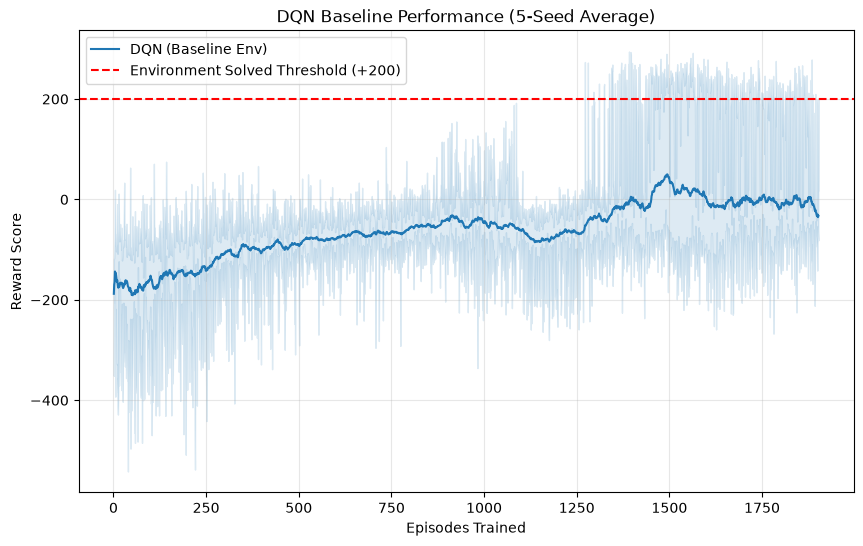

In [7]:
all_rewards_per_seed = []
common_timesteps = None

for seed in final_seeds:
    data = pd.read_csv(f"dqn_seed_{seed}_log.monitor.csv", skiprows=1)
    data['timesteps'] = data['l'].cumsum()
    all_rewards_per_seed.append(data['r'].values)

min_len = min(len(r) for r in all_rewards_per_seed)
all_rewards_per_seed = np.array([r[:min_len] for r in all_rewards_per_seed])

episodes = np.arange(1, min_len + 1)

mean_across_seeds = all_rewards_per_seed.mean(axis=0)
min_across_seeds = all_rewards_per_seed.min(axis=0)
max_across_seeds = all_rewards_per_seed.max(axis=0)

window = 20
mean_smooth = pd.Series(mean_across_seeds).rolling(window, min_periods=1).mean()

plt.figure(figsize=(10, 6))
plt.plot(episodes, mean_smooth, label="DQN (Baseline Env)", color="tab:blue")
plt.fill_between(episodes, min_across_seeds, max_across_seeds, alpha=0.15, color="tab:blue")
plt.axhline(y=200, color="red", linestyle="--", label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("DQN Baseline Performance (5-Seed Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Testing Best Vanilla DQN Models

In [22]:
NUM_EVAL_EPISODES = 100

all_seed_mean_rewards = []
all_seed_success_rates = []
all_seed_crash_rates = []

all_test_rewards_data = {}

env = gym.make("LunarLander-v3")

print(" Starting 5-Seed evaluation ...\n")

for seed in final_seeds:
    model_path = f"./dqn/best_dqn_seed_{seed}/best_model.zip"
    model = DQN.load(model_path, env=env)
    
    seed_rewards = []
    successes = 0
    crashes = 0
    
    for ep in range(NUM_EVAL_EPISODES):
        obs, _ = env.reset()
        done = False
        truncated = False
        total_reward = 0
        
        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            total_reward += reward
            
            if done or truncated:
                if reward >= 100:
                    successes += 1
                elif reward <= -100:
                    crashes += 1
                    
        seed_rewards.append(total_reward)
    
    seed_mean_reward = np.mean(seed_rewards)
    seed_success_rate = (successes / NUM_EVAL_EPISODES) * 100
    seed_crash_rate = (crashes / NUM_EVAL_EPISODES) * 100
    
    all_seed_mean_rewards.append(seed_mean_reward)
    all_seed_success_rates.append(seed_success_rate)
    all_seed_crash_rates.append(seed_crash_rate)
    all_test_rewards_data[f"Seed {seed}"] = seed_rewards
    
    print(f" Seed {seed} raw metrics:")
    print(f"Mean Reward: {seed_mean_reward:.2f}")
    print(f"Success Rate: {seed_success_rate:.1f}%")
    print(f"Crash Rate: {seed_crash_rate:.1f}%\n")

env.close()

final_reward_mean = np.mean(all_seed_mean_rewards)
final_reward_std = np.std(all_seed_mean_rewards)
final_success_mean = np.mean(all_seed_success_rates)
final_crash_mean = np.mean(all_seed_crash_rates)

print(" Final 5-seed metrics averages(DQN - Baseline):")
print(f"Overall Mean Reward: {final_reward_mean:.2f} +/- {final_reward_std:.2f}")
print(f"Overall Success Rate: {final_success_mean:.1f}%")
print(f"Overall Crash Rate: {final_crash_mean:.1f}%")

 Starting 5-Seed evaluation ...

 Seed 42 raw metrics:
Mean Reward: -45.79
Success Rate: 8.0%
Crash Rate: 20.0%

 Seed 84 raw metrics:
Mean Reward: -28.79
Success Rate: 2.0%
Crash Rate: 13.0%

 Seed 146 raw metrics:
Mean Reward: 132.07
Success Rate: 60.0%
Crash Rate: 3.0%

 Seed 1447 raw metrics:
Mean Reward: 176.66
Success Rate: 72.0%
Crash Rate: 18.0%

 Seed 2026 raw metrics:
Mean Reward: 164.84
Success Rate: 74.0%
Crash Rate: 15.0%

 Final 5-seed metrics averages(DQN - Baseline):
Overall Mean Reward: 79.80 +/- 96.86
Overall Success Rate: 43.2%
Overall Crash Rate: 13.8%


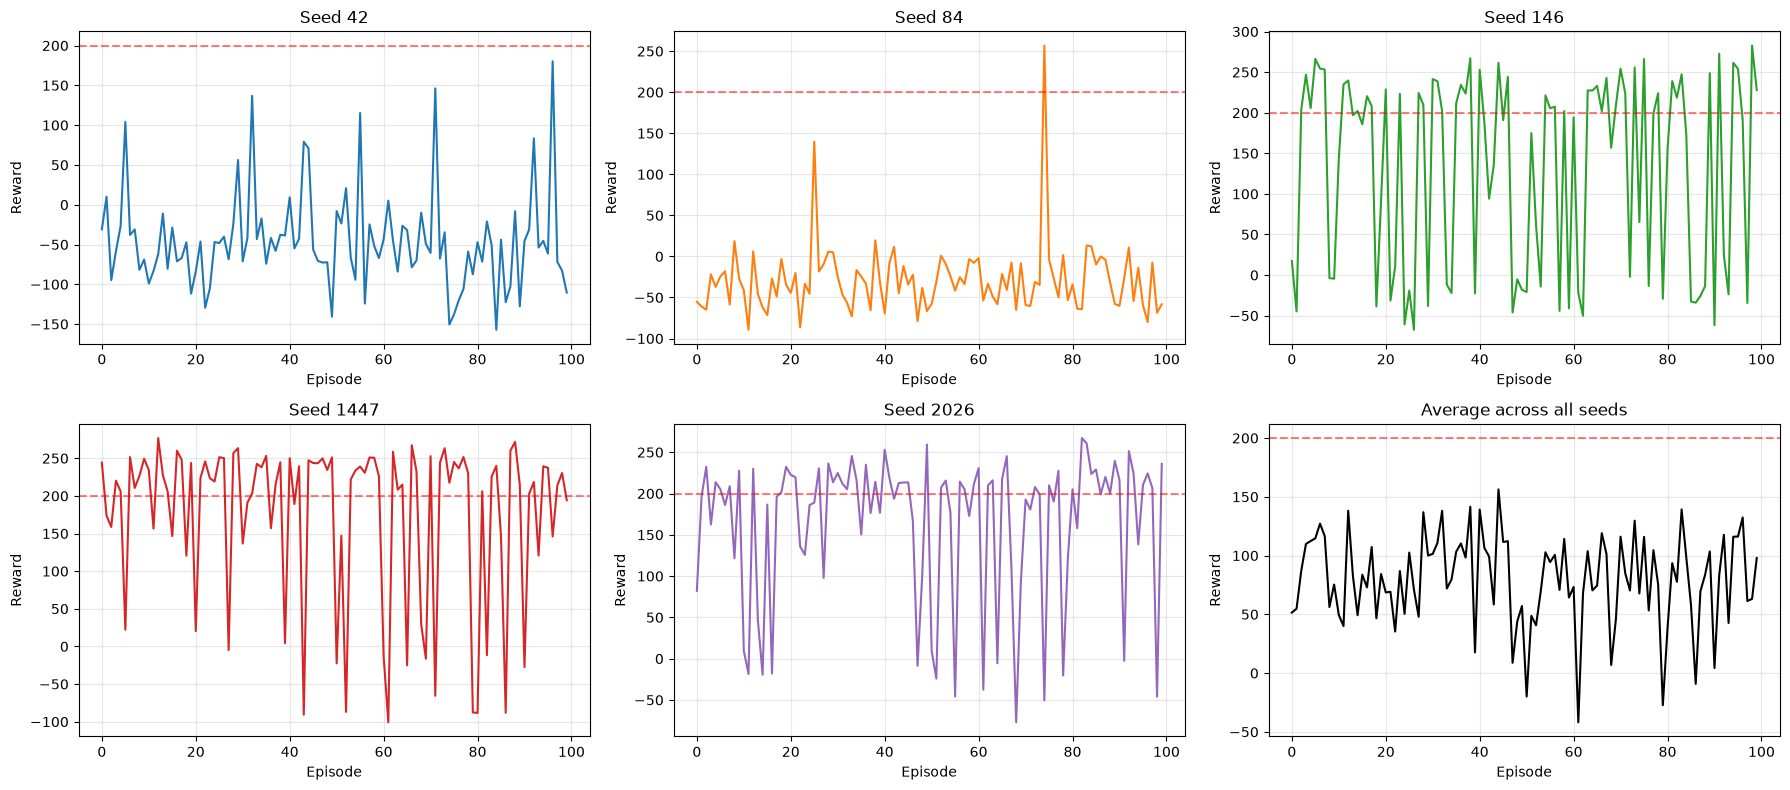

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

seed_names = list(all_test_rewards_data.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, seed_name in enumerate(seed_names):
    rewards = all_test_rewards_data[seed_name]
    axes[i].plot(rewards, color=colors[i])
    axes[i].axhline(y=200, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(seed_name)
    axes[i].set_xlabel("Episode")
    axes[i].set_ylabel("Reward")
    axes[i].grid(True, alpha=0.3)

avg_rewards = np.mean([all_test_rewards_data[s] for s in seed_names], axis=0)
axes[5].plot(avg_rewards, color='black')
axes[5].axhline(y=200, color='red', linestyle='--', alpha=0.5)
axes[5].set_title("Average across all seeds")
axes[5].set_xlabel("Episode")
axes[5].set_ylabel("Reward")
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

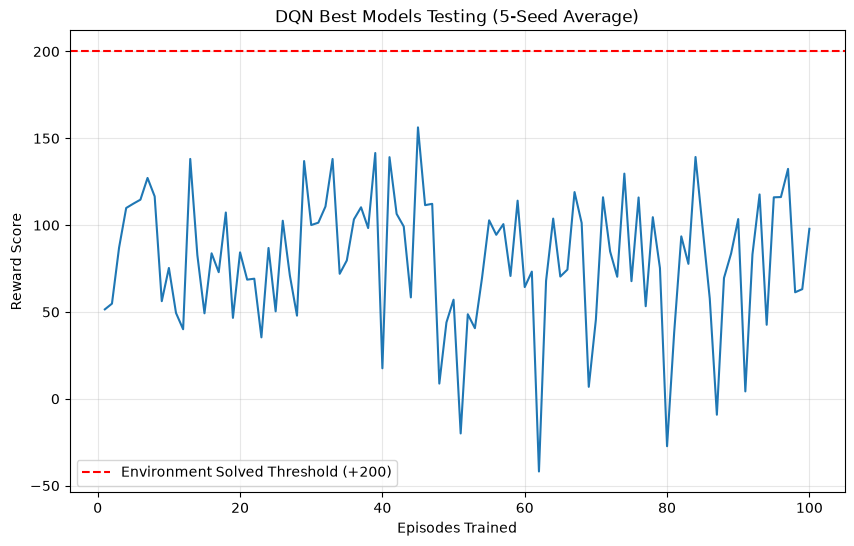

In [26]:
plt.figure(figsize=(10, 6))
plt.plot(episodes, avg_rewards, color="tab:blue")
plt.axhline(y=200, color="red", linestyle="--", label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("DQN Best Models Testing (5-Seed Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

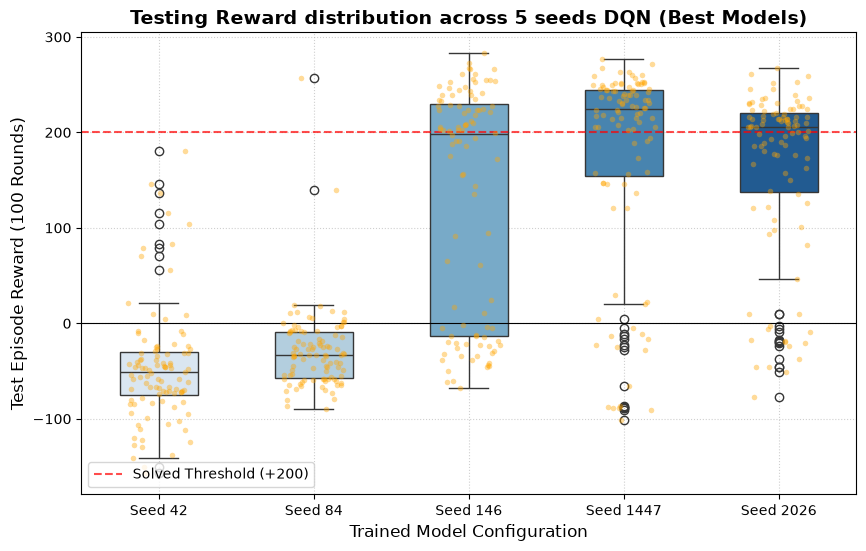

In [25]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=list(all_test_rewards_data.values()), palette="Blues", width=0.5)
sns.stripplot(data=list(all_test_rewards_data.values()), color="orange", alpha=0.4, size=4, jitter=0.2)

plt.xticks(ticks=range(len(final_seeds)), labels=list(all_test_rewards_data.keys()))

plt.axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Solved Threshold (+200)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.title("Testing Reward distribution across 5 seeds DQN (Best Models)", fontsize=14, fontweight='bold')
plt.xlabel("Trained Model Configuration", fontsize=12)
plt.ylabel("Test Episode Reward (100 Rounds)", fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

### Double DQN Test

#### Training Double DQN Model

In [15]:

all_results = []

for seed in final_seeds:
    print(f"\n=== Training Double DQN with seed={seed} ===")

    train_env = gym.make("LunarLander-v3")
    train_env = Monitor(train_env, f"double_dqn/dqn_seed_{seed}_log")

    eval_env = gym.make("LunarLander-v3")
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"double_dqn/best_dqn_seed_{seed}/",
        log_path=f"double_dqn/eval_logs_seed_{seed}/",
        eval_freq=10_000,
        n_eval_episodes=5,
        deterministic=True
    )

    model = DoubleDQN(
        "MlpPolicy",
        train_env,
        learning_rate=1e-4,
        gamma=0.99,
        exploration_fraction=0.2,
        target_update_interval=1000,
        verbose=0,
        seed=seed,
    )

    model.learn(total_timesteps=1_000_000, callback=eval_callback)
    model.save(f"double_dqn/dqn_lunarlander_seed_{seed}")

    best_model = DoubleDQN.load(f"double_dqn/best_dqn_seed_{seed}/best_model")  # ← وهنا
    mean_reward, std_reward = evaluate_policy(best_model, eval_env, n_eval_episodes=20)

    print(f"Seed {seed} -> Best model reward: {mean_reward:.2f} +/- {std_reward:.2f}")
    all_results.append(mean_reward)

all_results = np.array(all_results)
print(f"\n=== Final Result Across {len(final_seeds)} Seeds (Double DQN) ===")
print(f"Mean: {all_results.mean():.2f} +/- {all_results.std():.2f}")


=== Training Double DQN with seed=42 ===
Eval num_timesteps=10000, episode_reward=-2709.78 +/- 138.09
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=20000, episode_reward=-130.54 +/- 5.44
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=30000, episode_reward=-71.00 +/- 14.55
Episode length: 1000.00 +/- 0.00
New best mean reward!
Eval num_timesteps=40000, episode_reward=-84.87 +/- 17.34
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=50000, episode_reward=-77.07 +/- 18.67
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=60000, episode_reward=-104.57 +/- 26.34
Episode length: 854.60 +/- 183.58
Eval num_timesteps=70000, episode_reward=-115.76 +/- 32.25
Episode length: 359.60 +/- 139.55
Eval num_timesteps=80000, episode_reward=-161.47 +/- 48.90
Episode length: 577.00 +/- 325.35
Eval num_timesteps=90000, episode_reward=-179.71 +/- 42.73
Episode length: 525.20 +/- 230.09
Eval num_timesteps=100000, episode_reward=-136.77 +/- 8.07
Epi

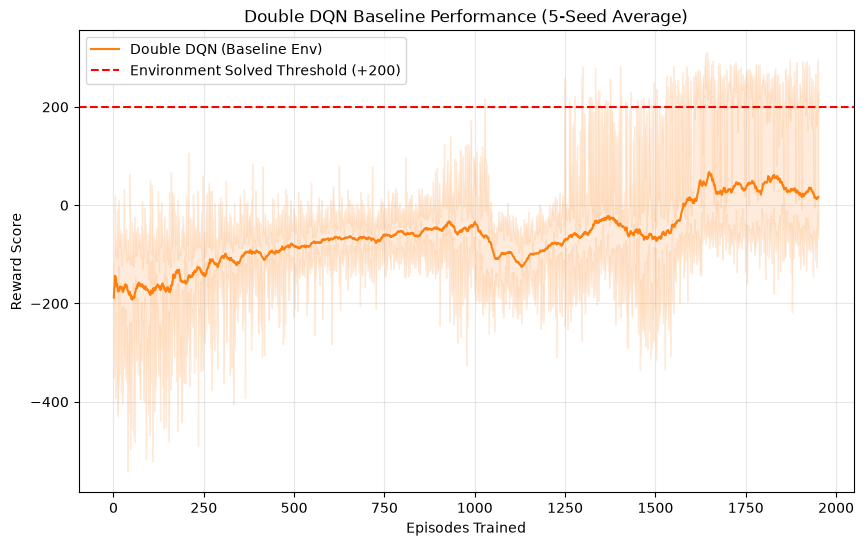

In [16]:
all_rewards_per_seed = []

for seed in final_seeds:
    data = pd.read_csv(f"double_dqn/dqn_seed_{seed}_log.monitor.csv", skiprows=1)
    data['timesteps'] = data['l'].cumsum()
    all_rewards_per_seed.append(data['r'].values)

min_len = min(len(r) for r in all_rewards_per_seed)
all_rewards_per_seed = np.array([r[:min_len] for r in all_rewards_per_seed])

episodes = np.arange(1, min_len + 1)

mean_across_seeds = all_rewards_per_seed.mean(axis=0)
min_across_seeds = all_rewards_per_seed.min(axis=0)
max_across_seeds = all_rewards_per_seed.max(axis=0)

window = 20
mean_smooth = pd.Series(mean_across_seeds).rolling(window, min_periods=1).mean()

plt.figure(figsize=(10, 6))
plt.plot(episodes, mean_smooth, label="Double DQN (Baseline Env)", color="tab:orange")
plt.fill_between(episodes, min_across_seeds, max_across_seeds, alpha=0.15, color="tab:orange")
plt.axhline(y=200, color="red", linestyle="--", label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("Double DQN Baseline Performance (5-Seed Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

#### Testing Double DQN Best Models

In [27]:
NUM_EVAL_EPISODES = 100

all_seed_mean_rewards = []
all_seed_success_rates = []
all_seed_crash_rates = []

all_test_rewards_data = {}

env = gym.make("LunarLander-v3")

print(" Starting 5-Seed evaluation ...\n")

for seed in final_seeds:
    model_path = f"./double_dqn/best_dqn_seed_{seed}/best_model.zip"
    model = DQN.load(model_path, env=env)
    
    seed_rewards = []
    successes = 0
    crashes = 0
    
    for ep in range(NUM_EVAL_EPISODES):
        obs, _ = env.reset()
        done = False
        truncated = False
        total_reward = 0
        
        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            total_reward += reward
            
            if done or truncated:
                if reward >= 100:
                    successes += 1
                elif reward <= -100:
                    crashes += 1
                    
        seed_rewards.append(total_reward)
    
    seed_mean_reward = np.mean(seed_rewards)
    seed_success_rate = (successes / NUM_EVAL_EPISODES) * 100
    seed_crash_rate = (crashes / NUM_EVAL_EPISODES) * 100
    
    all_seed_mean_rewards.append(seed_mean_reward)
    all_seed_success_rates.append(seed_success_rate)
    all_seed_crash_rates.append(seed_crash_rate)
    all_test_rewards_data[f"Seed {seed}"] = seed_rewards
    
    print(f" Seed {seed} raw metrics:")
    print(f"Mean Reward: {seed_mean_reward:.2f}")
    print(f"Success Rate: {seed_success_rate:.1f}%")
    print(f"Crash Rate: {seed_crash_rate:.1f}%\n")

env.close()

final_reward_mean = np.mean(all_seed_mean_rewards)
final_reward_std = np.std(all_seed_mean_rewards)
final_success_mean = np.mean(all_seed_success_rates)
final_crash_mean = np.mean(all_seed_crash_rates)

print(" Final 5-seed metrics averages(DQN - Baseline):")
print(f"Overall Mean Reward: {final_reward_mean:.2f} +/- {final_reward_std:.2f}")
print(f"Overall Success Rate: {final_success_mean:.1f}%")
print(f"Overall Crash Rate: {final_crash_mean:.1f}%")

 Starting 5-Seed evaluation ...

 Seed 42 raw metrics:
Mean Reward: 148.66
Success Rate: 76.0%
Crash Rate: 12.0%

 Seed 84 raw metrics:
Mean Reward: 24.93
Success Rate: 31.0%
Crash Rate: 33.0%

 Seed 146 raw metrics:
Mean Reward: 173.37
Success Rate: 77.0%
Crash Rate: 10.0%

 Seed 1447 raw metrics:
Mean Reward: 222.94
Success Rate: 90.0%
Crash Rate: 3.0%

 Seed 2026 raw metrics:
Mean Reward: 138.25
Success Rate: 32.0%
Crash Rate: 5.0%

 Final 5-seed metrics averages(DQN - Baseline):
Overall Mean Reward: 141.63 +/- 65.27
Overall Success Rate: 61.2%
Overall Crash Rate: 12.6%


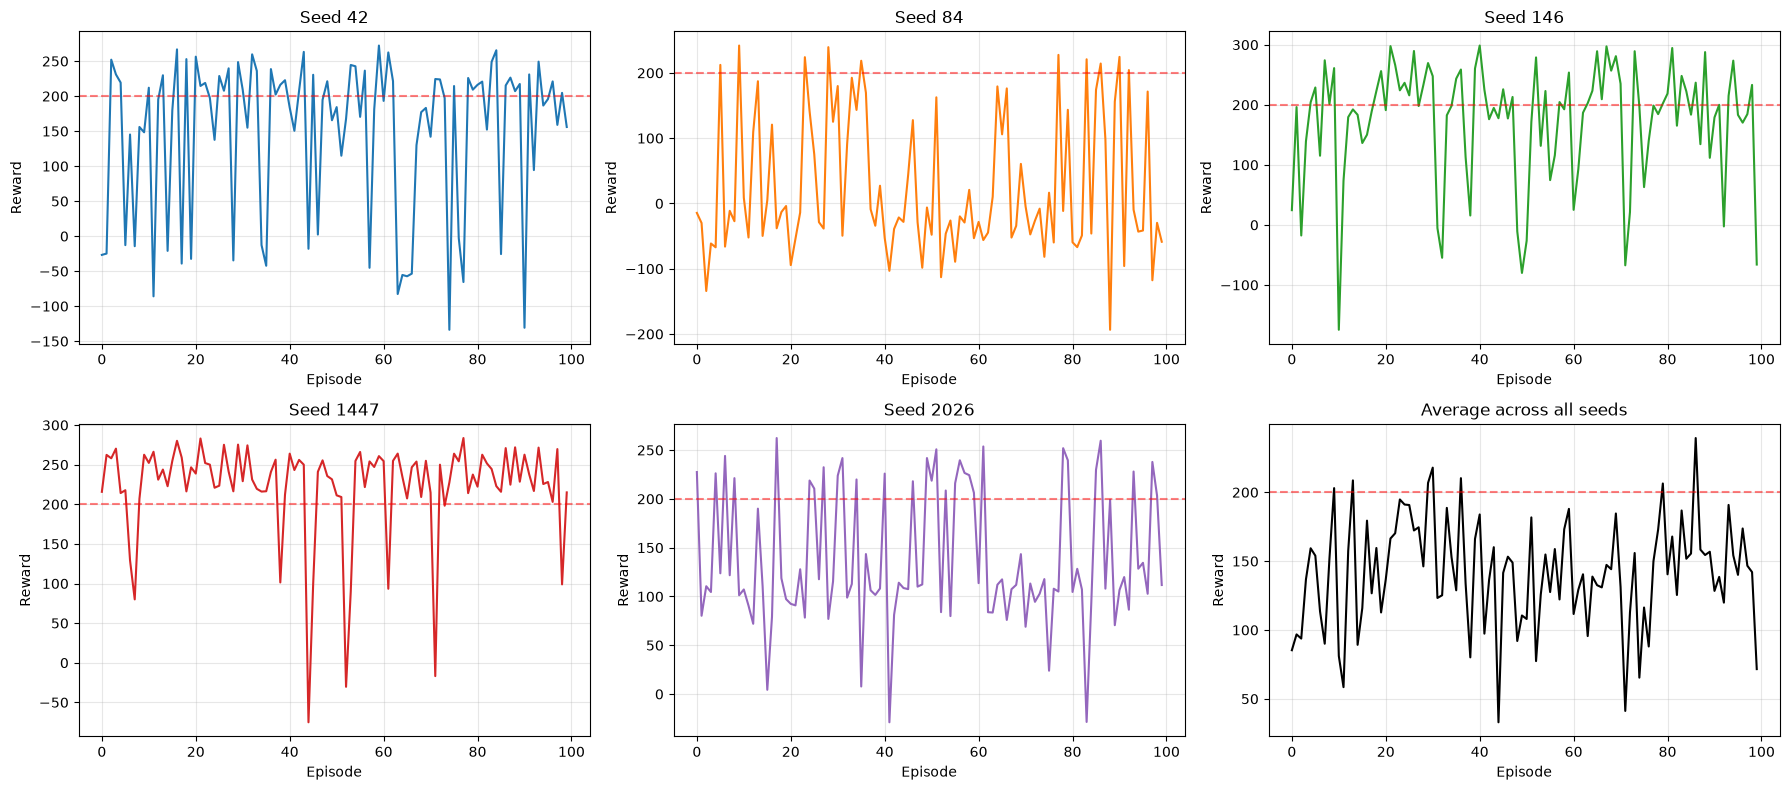

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

seed_names = list(all_test_rewards_data.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, seed_name in enumerate(seed_names):
    rewards = all_test_rewards_data[seed_name]
    axes[i].plot(rewards, color=colors[i])
    axes[i].axhline(y=200, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(seed_name)
    axes[i].set_xlabel("Episode")
    axes[i].set_ylabel("Reward")
    axes[i].grid(True, alpha=0.3)

avg_rewards = np.mean([all_test_rewards_data[s] for s in seed_names], axis=0)
axes[5].plot(avg_rewards, color='black')
axes[5].axhline(y=200, color='red', linestyle='--', alpha=0.5)
axes[5].set_title("Average across all seeds")
axes[5].set_xlabel("Episode")
axes[5].set_ylabel("Reward")
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

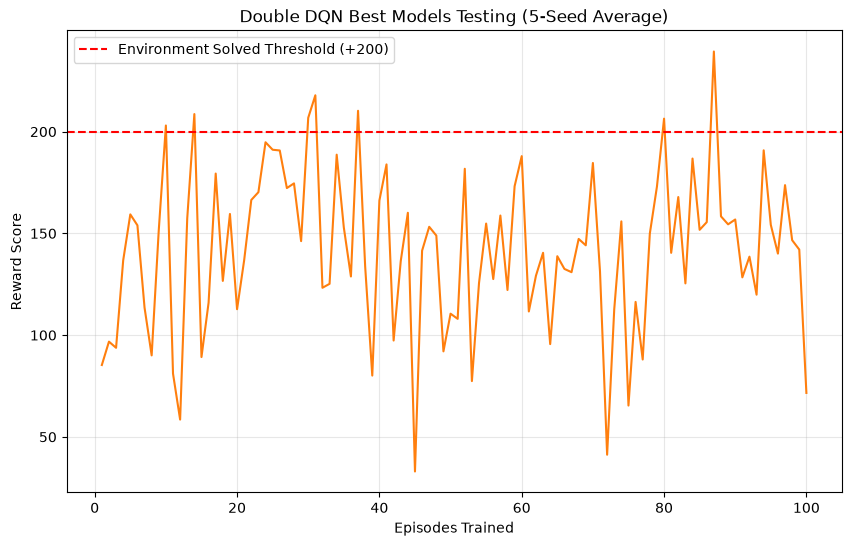

In [29]:
plt.figure(figsize=(10, 6))
plt.plot(episodes, avg_rewards, color="tab:orange")
plt.axhline(y=200, color="red", linestyle="--", label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("Double DQN Best Models Testing (5-Seed Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

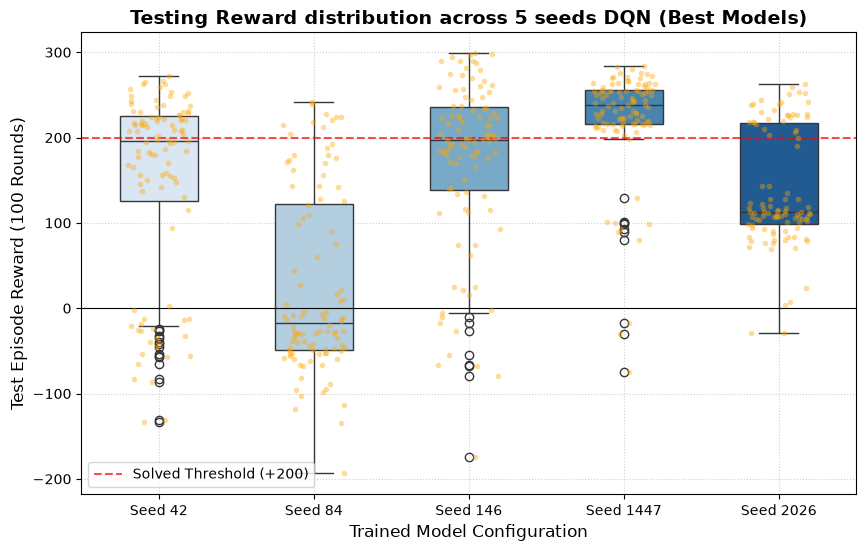

In [30]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=list(all_test_rewards_data.values()), palette="Blues", width=0.5)
sns.stripplot(data=list(all_test_rewards_data.values()), color="orange", alpha=0.4, size=4, jitter=0.2)

plt.xticks(ticks=range(len(final_seeds)), labels=list(all_test_rewards_data.keys()))

plt.axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Solved Threshold (+200)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.title("Testing Reward distribution across 5 seeds DQN (Best Models)", fontsize=14, fontweight='bold')
plt.xlabel("Trained Model Configuration", fontsize=12)
plt.ylabel("Test Episode Reward (100 Rounds)", fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

### Dueling DQN Test

#### Training Dueling DQN Model

In [6]:

all_results = []

for seed in final_seeds:
    print(f"\n=== Training Dueling DQN with seed={seed} ===")

    train_env = gym.make("LunarLander-v3")
    train_env = Monitor(train_env, f"dueling_dqn/dqn_seed_{seed}_log")

    eval_env = gym.make("LunarLander-v3")
    
    eval_callback = EvalCallback(
        eval_env,
        best_model_save_path=f"dueling_dqn/best_dqn_seed_{seed}/",
        log_path=f"dueling_dqn/eval_logs_seed_{seed}/",
        eval_freq=10_000,
        n_eval_episodes=5,
        deterministic=True
    )

    model = DuelingDQN(
        "MlpPolicy",
        train_env,
        learning_rate=1e-4,
        gamma=0.99,
        exploration_fraction=0.2,
        target_update_interval=1000,
        verbose=0,
        seed=seed,
    )

    model.learn(total_timesteps=1_000_000, callback=eval_callback)
    
    model.save(f"dueling_dqn/dqn_lunarlander_seed_{seed}")

    best_model = DuelingDQN.load(f"dueling_dqn/best_dqn_seed_{seed}/best_model")
    mean_reward, std_reward = evaluate_policy(best_model, eval_env, n_eval_episodes=20)

    print(f"Seed {seed} -> Best model reward: {mean_reward:.2f} +/- {std_reward:.2f}")
    all_results.append(mean_reward)

all_results = np.array(all_results)
print(f"\n=== Final Result Across {len(final_seeds)} Seeds (Dueling DQN) ===")
print(f"Mean: {all_results.mean():.2f} +/- {all_results.std():.2f}")


=== Training Dueling DQN with seed=42 ===


c:\Users\DPQUAI250105\AppData\Local\miniconda3\envs\rl_env\Lib\site-packages\stable_baselines3\common\evaluation.py:71: UserWarning: Evaluation environment is not wrapped with a ``Monitor`` wrapper. This may result in reporting modified episode lengths and rewards, if other wrappers happen to modify these. Consider wrapping environment first with ``Monitor`` wrapper.
  warnings.warn(


Eval num_timesteps=10000, episode_reward=-68.49 +/- 168.60
Episode length: 267.60 +/- 76.59
New best mean reward!
Eval num_timesteps=20000, episode_reward=-95.27 +/- 19.18
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=30000, episode_reward=-99.13 +/- 13.40
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=40000, episode_reward=-174.67 +/- 44.12
Episode length: 546.60 +/- 167.16
Eval num_timesteps=50000, episode_reward=-135.05 +/- 44.52
Episode length: 324.20 +/- 66.52
Eval num_timesteps=60000, episode_reward=-128.39 +/- 39.89
Episode length: 289.00 +/- 103.82
Eval num_timesteps=70000, episode_reward=-160.21 +/- 16.83
Episode length: 480.60 +/- 19.40
Eval num_timesteps=80000, episode_reward=-140.89 +/- 33.38
Episode length: 601.40 +/- 339.59
Eval num_timesteps=90000, episode_reward=-134.22 +/- 18.50
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=100000, episode_reward=-123.94 +/- 27.49
Episode length: 1000.00 +/- 0.00
Eval num_timesteps=110000, episode_reward=-91.66 +/- 23.

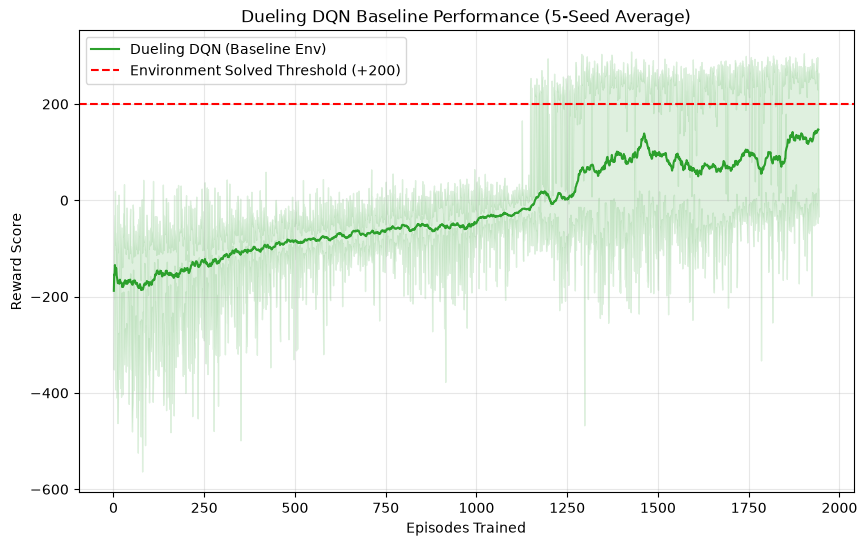

In [8]:
all_rewards_per_seed = []

for seed in final_seeds:
    data = pd.read_csv(f"dueling_dqn/dqn_seed_{seed}_log.monitor.csv", skiprows=1)
    data['timesteps'] = data['l'].cumsum()
    all_rewards_per_seed.append(data['r'].values)

min_len = min(len(r) for r in all_rewards_per_seed)
all_rewards_per_seed = np.array([r[:min_len] for r in all_rewards_per_seed])

episodes = np.arange(1, min_len + 1)

mean_across_seeds = all_rewards_per_seed.mean(axis=0)
min_across_seeds = all_rewards_per_seed.min(axis=0)
max_across_seeds = all_rewards_per_seed.max(axis=0)

window = 20
mean_smooth = pd.Series(mean_across_seeds).rolling(window, min_periods=1).mean()

plt.figure(figsize=(10, 6))
plt.plot(episodes, mean_smooth, label="Dueling DQN (Baseline Env)", color="tab:green")
plt.fill_between(episodes, min_across_seeds, max_across_seeds, alpha=0.15, color="tab:green")
plt.axhline(y=200, color="red", linestyle="--", label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("Dueling DQN Baseline Performance (5-Seed Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Testing Dueling DQN Best Models

In [32]:
NUM_EVAL_EPISODES = 100

all_seed_mean_rewards = []
all_seed_success_rates = []
all_seed_crash_rates = []

all_test_rewards_data = {}

env = gym.make("LunarLander-v3")

print(" Starting 5-Seed evaluation ...\n")

for seed in final_seeds:
    model_path = f"./dueling_dqn/best_dqn_seed_{seed}/best_model.zip"
    model = DQN.load(model_path, env=env)
    
    seed_rewards = []
    successes = 0
    crashes = 0
    
    for ep in range(NUM_EVAL_EPISODES):
        obs, _ = env.reset()
        done = False
        truncated = False
        total_reward = 0
        
        while not (done or truncated):
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, done, truncated, info = env.step(action)
            total_reward += reward
            
            if done or truncated:
                if reward >= 100:
                    successes += 1
                elif reward <= -100:
                    crashes += 1
                    
        seed_rewards.append(total_reward)
    
    seed_mean_reward = np.mean(seed_rewards)
    seed_success_rate = (successes / NUM_EVAL_EPISODES) * 100
    seed_crash_rate = (crashes / NUM_EVAL_EPISODES) * 100
    
    all_seed_mean_rewards.append(seed_mean_reward)
    all_seed_success_rates.append(seed_success_rate)
    all_seed_crash_rates.append(seed_crash_rate)
    all_test_rewards_data[f"Seed {seed}"] = seed_rewards
    
    print(f" Seed {seed} raw metrics:")
    print(f"Mean Reward: {seed_mean_reward:.2f}")
    print(f"Success Rate: {seed_success_rate:.1f}%")
    print(f"Crash Rate: {seed_crash_rate:.1f}%\n")

env.close()

final_reward_mean = np.mean(all_seed_mean_rewards)
final_reward_std = np.std(all_seed_mean_rewards)
final_success_mean = np.mean(all_seed_success_rates)
final_crash_mean = np.mean(all_seed_crash_rates)

print(" Final 5-seed metrics averages(DQN - Baseline):")
print(f"Overall Mean Reward: {final_reward_mean:.2f} +/- {final_reward_std:.2f}")
print(f"Overall Success Rate: {final_success_mean:.1f}%")
print(f"Overall Crash Rate: {final_crash_mean:.1f}%")

 Starting 5-Seed evaluation ...

 Seed 42 raw metrics:
Mean Reward: 190.38
Success Rate: 76.0%
Crash Rate: 9.0%

 Seed 84 raw metrics:
Mean Reward: 79.77
Success Rate: 38.0%
Crash Rate: 0.0%

 Seed 146 raw metrics:
Mean Reward: 246.49
Success Rate: 89.0%
Crash Rate: 5.0%

 Seed 1447 raw metrics:
Mean Reward: -3.20
Success Rate: 0.0%
Crash Rate: 0.0%

 Seed 2026 raw metrics:
Mean Reward: 234.21
Success Rate: 88.0%
Crash Rate: 8.0%

 Final 5-seed metrics averages(DQN - Baseline):
Overall Mean Reward: 149.53 +/- 96.37
Overall Success Rate: 58.2%
Overall Crash Rate: 4.4%


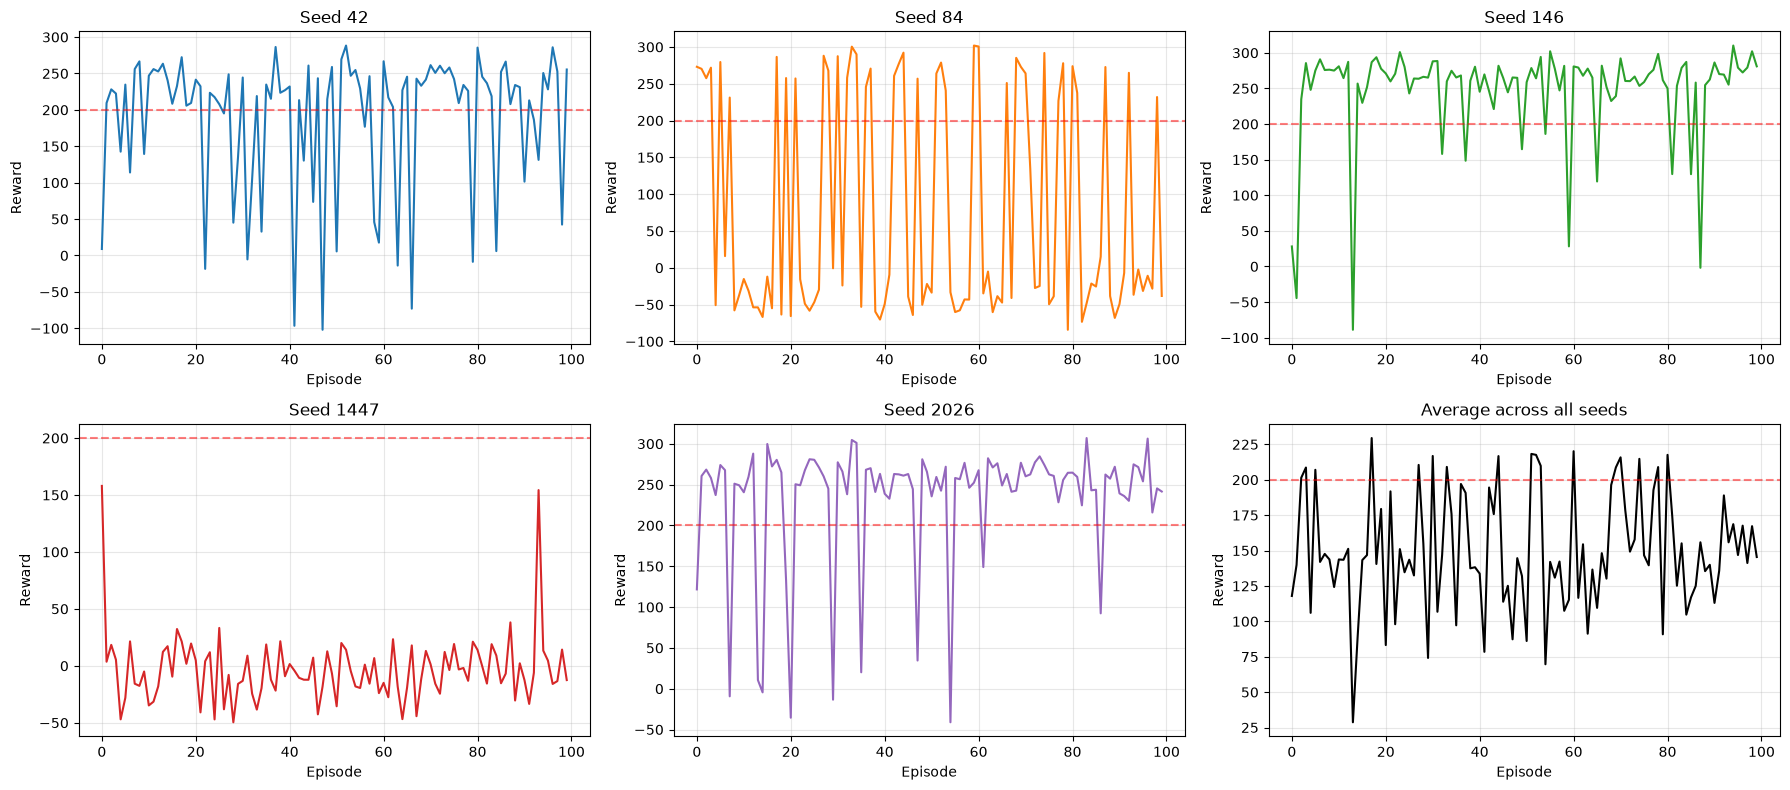

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
axes = axes.flatten()

seed_names = list(all_test_rewards_data.keys())
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

for i, seed_name in enumerate(seed_names):
    rewards = all_test_rewards_data[seed_name]
    axes[i].plot(rewards, color=colors[i])
    axes[i].axhline(y=200, color='red', linestyle='--', alpha=0.5)
    axes[i].set_title(seed_name)
    axes[i].set_xlabel("Episode")
    axes[i].set_ylabel("Reward")
    axes[i].grid(True, alpha=0.3)

avg_rewards = np.mean([all_test_rewards_data[s] for s in seed_names], axis=0)
axes[5].plot(avg_rewards, color='black')
axes[5].axhline(y=200, color='red', linestyle='--', alpha=0.5)
axes[5].set_title("Average across all seeds")
axes[5].set_xlabel("Episode")
axes[5].set_ylabel("Reward")
axes[5].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

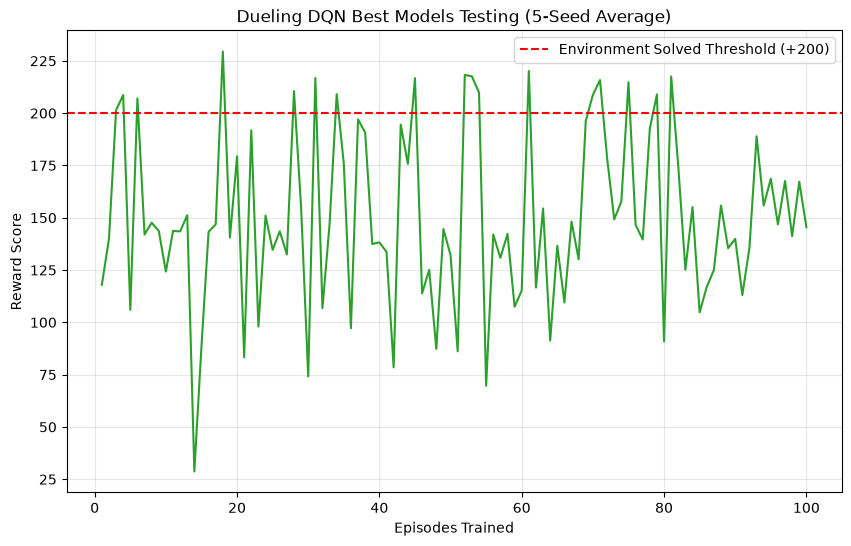

In [34]:
plt.figure(figsize=(10, 6))
plt.plot(episodes, avg_rewards, color="tab:green")
plt.axhline(y=200, color="red", linestyle="--", label="Environment Solved Threshold (+200)")
plt.xlabel("Episodes Trained")
plt.ylabel("Reward Score")
plt.title("Dueling DQN Best Models Testing (5-Seed Average)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

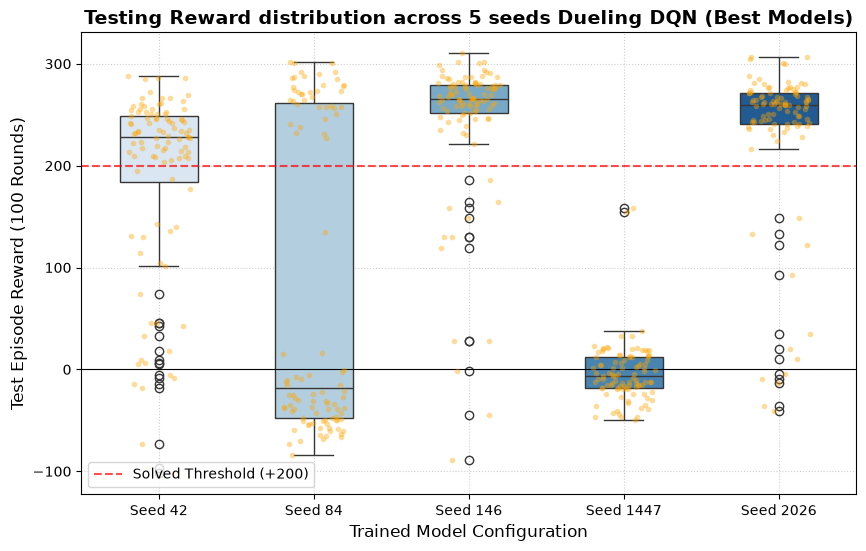

In [35]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=list(all_test_rewards_data.values()), palette="Blues", width=0.5)
sns.stripplot(data=list(all_test_rewards_data.values()), color="orange", alpha=0.4, size=4, jitter=0.2)

plt.xticks(ticks=range(len(final_seeds)), labels=list(all_test_rewards_data.keys()))

plt.axhline(y=200, color='red', linestyle='--', alpha=0.7, label='Solved Threshold (+200)')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

plt.title("Testing Reward distribution across 5 seeds Dueling DQN (Best Models)", fontsize=14, fontweight='bold')
plt.xlabel("Trained Model Configuration", fontsize=12)
plt.ylabel("Test Episode Reward (100 Rounds)", fontsize=12)
plt.legend(loc="lower left")
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()